<a href="https://colab.research.google.com/github/cmunozr/2026_I_AI_GU/blob/main/Project/deepmaxent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌿 DeepMaxent: Species Distribution Modeling

## Introduction

---

## 📋 Contents

1. [Import Libraries](#1-import-libraries)
2. [Load Biodiversity Data](#2-load-biodiversity-data)
3. [Data Exploration & Visualization](#3-data-exploration)
4. [Crop Environmental Rasters](#4-crop-rasters)
5. [Visualize Environmental Variables](#5-visualize-environment)
6. [Prepare Training Data](#6-prepare-data)
7. [Summary Statistics](#7-summary)

<a id="1-import-libraries"></a>
## 1. Import Libraries

We need several libraries for this tutorial:
- **pandas/numpy**: Data manipulation
- **rasterio**: Reading and processing raster files
- **matplotlib/cartopy**: Creating beautiful maps
- **torch**: Building tensors for deep learning
- **sklearn**: Data preprocessing

In [ ]:
pip install cartopy verde

In [ ]:
!git clone https://github.com/RYCKEWAERT/deepmaxent.git

In [ ]:
import sys
sys.path.append('/content/deepmaxent')

In [ ]:
# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Core libraries
import numpy as np
import pandas as pd
import os
from tqdm import tqdm

# Geospatial libraries
import rasterio
from rasterio.windows import from_bounds
from rasterio.plot import show

# Machine Learning
import torch
from sklearn.preprocessing import StandardScaler

# Visualization
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# DeepMaxent libraries
from librairies.model import deepmaxent_model
from librairies.losses import deepmaxent_loss
from librairies.utils import set_seed

# Set random seed for reproducibility
set_seed(42)

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("✅ All libraries loaded successfully!")

<a id="2-load-biodiversity-data"></a>
## 2. Load Biodiversity Data

We'll load occurrence data from the **Finnish biodiversity Survey**.

In [ ]:
!git clone https://github.com/cmunozr/2026_I_AI_GU

In [ ]:
import pandas as pd

# Load the biodiversity dataset
df = pd.read_csv('/content/2026_I_AI_GU/Project/data/YData.csv', sep=',', low_memory=False)

print(f"📊 Dataset shape: {df.shape[0]:,} observations × {df.shape[1]} columns")
print(f"\n🔤 Available columns:\n{df.columns.tolist()[:15]}...")

# Display first few rows
df.head(3)

<a id="3-data-exploration"></a>
## 3. 🔍 Data Exploration & Visualization

Let's explore the dataset to understand what kind of data we have:

In [ ]:
# Clean coordinates and filter valid data
df_xy = pd.read_csv('/content/2026_I_AI_GU/Project/data/xy.csv', sep=',', low_memory=False)
df_xy['decimalLatitude'] = pd.to_numeric(df_xy['Y'], errors='coerce')
df_xy['decimalLongitude'] = pd.to_numeric(df_xy['X'], errors='coerce')

print(f"📍 Valid observations with coordinates: {len(df_xy):,}")

In [ ]:
df_year = pd.read_csv("/content/2026_I_AI_GU/Project/data/year.csv")

In [ ]:
# Reconstruct a long-format DataFrame of species occurrences to follow and keep on tutorial

# Combine coordinates with species presence/absence and year data
df_combined_coords_species = pd.concat(
    [df_xy[['decimalLongitude', 'decimalLatitude']], df, df_year.rename(columns={'studyDesign$year': 'year'})],
    axis=1
)

# Melt the DataFrame to long format to get one row per species observation
# This will create a 'species' column and a 'presence' column (0 or 1)
df_observations = df_combined_coords_species.melt(
    id_vars=['decimalLongitude', 'decimalLatitude', 'year'],
    var_name='species',
    value_name='presence'
)

# Filter for actual presences (presence == 1)
df_observations = df_observations[df_observations['presence'] == 1].drop(columns=['presence'])

display(df_observations.head())

# Rename df_observations to df_filtered for consistency with original notebook's variable naming
# This will prevent needing to change variable names in many subsequent cells.
df_filtered = df_observations

### 3.1 Map of Species Occurrences

Let's visualize where the species observations are located. This is crucial to understand the spatial distribution of our data and identify potential sampling biases.

In [ ]:
# Create a beautiful map showing all occurrences
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Define map extent with padding
padding = 0.5
extent = [
    df_filtered['decimalLongitude'].min() - padding,
    df_filtered['decimalLongitude'].max() + padding,
    df_filtered['decimalLatitude'].min() - padding,
    df_filtered['decimalLatitude'].max() + padding
]
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, facecolor='#f0f0f0', edgecolor='none')
ax.add_feature(cfeature.OCEAN, facecolor='#cce5ff')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='#555555')
ax.add_feature(cfeature.BORDERS, linestyle='--', linewidth=0.5, edgecolor='#888888')
ax.add_feature(cfeature.RIVERS, linewidth=0.5, edgecolor='#99ccff')

# Plot occurrence points
scatter = ax.scatter(
    df_filtered['decimalLongitude'],
    df_filtered['decimalLatitude'],
    c='#2ecc71',
    s=15,
    alpha=0.6,
    edgecolor='#27ae60',
    linewidth=0.3,
    transform=ccrs.PlateCarree(),
    label='Bird occurrences'
)

# Add gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

# Title and legend
ax.set_title('Bird Species Occurrences in Costa Rica\n(FBS Data - Human Observations)',
             fontsize=16, fontweight='bold', pad=20)
ax.legend(loc='lower left', fontsize=11)

# Add observation count annotation
ax.text(0.02, 0.1, f'n = {len(df_filtered):,} observations',
        transform=ax.transAxes, fontsize=11,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

### 3.2 Top Species Distribution

Let's look at the most frequently observed species in our dataset:

In [ ]:
# Get species observation counts
species_counts = df_filtered['species'].value_counts()

# Top 10 most observed species
top_10_species = species_counts.head(10)

# Top 10 least observed species (excluding species with 0 observations if any, though value_counts handles this)
least_10_species = species_counts.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot Top 10 Most Observed Species
ax1 = axes[0]
colors_gradient_top = plt.cm.Greens(np.linspace(0.4, 0.9, len(top_10_species)))[::-1]
bars_top = ax1.barh(range(len(top_10_species)), top_10_species.values, color=colors_gradient_top)
ax1.set_yticks(range(len(top_10_species)))
ax1.set_yticklabels([f'$\it{{{s}}}$' for s in top_10_species.index], fontsize=10)
ax1.invert_yaxis()
ax1.set_xlabel('Number of Observations', fontsize=12)
ax1.set_title('Top 10 Most Observed Species', fontsize=14, fontweight='bold')
for i, (bar, val) in enumerate(zip(bars_top, top_10_species.values)):
    ax1.text(val + (top_10_species.values.max() * 0.02), i, f'{val:,}', va='center', fontsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Plot Top 10 Least Observed Species
ax2 = axes[1]
colors_gradient_least = plt.cm.Oranges(np.linspace(0.4, 0.9, len(least_10_species)))
bars_least = ax2.barh(range(len(least_10_species)), least_10_species.values, color=colors_gradient_least)
ax2.set_yticks(range(len(least_10_species)))
ax2.set_yticklabels([f'$\it{{{s}}}$' for s in least_10_species.index], fontsize=10)
ax2.invert_yaxis()
ax2.set_xlabel('Number of Observations', fontsize=12)
ax2.set_title('10 Least Observed Species', fontsize=14, fontweight='bold')
for i, (bar, val) in enumerate(zip(bars_least, least_10_species.values)):
    ax2.text(val + (least_10_species.values.max() * 0.05), i, f'{val:,}', va='center', fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f" Distribution summary:")
print(f"   Most observed species: {top_10_species.index[0]} ({top_10_species.values[0]:,} obs)")
print(f"   Least observed species: {least_10_species.index[-1]} ({least_10_species.values[-1]:,} obs)")
print(f"   Median obs per species: {species_counts.median():.0f}")
print(f"   Min obs per species: {species_counts.min():.0f}")

### 3.3 Temporal Distribution of Observations

Understanding when observations were made helps identify temporal sampling bias:

In [ ]:
# Temporal distribution
year_counts = df_filtered['year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 3))

ax.fill_between(year_counts.index, year_counts.values, alpha=0.4, color='#3498db')
ax.plot(year_counts.index, year_counts.values, color='#2980b9', linewidth=2, marker='o', markersize=4)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Observations', fontsize=12)
ax.set_title('Temporal Distribution of Plant Observations', fontsize=14, fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Highlight peak year
peak_year = year_counts.idxmax()
peak_count = year_counts.max()
ax.annotate(f'Peak: {peak_year}\n({peak_count:,} obs)',
            xy=(peak_year, peak_count),
            xytext=(peak_year-3, peak_count*0.85),
            fontsize=10,
            arrowprops=dict(arrowstyle='->', color='#e74c3c'),
            bbox=dict(boxstyle='round', facecolor='white', edgecolor='#e74c3c'))

plt.tight_layout()
plt.show()

### 3.4 Observation Density Heatmap

A density map helps identify areas with high sampling effort:

In [ ]:
# Create density heatmap
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Define map extent
padding = 0.5
extent = [
    df_filtered['decimalLongitude'].min() - padding,
    df_filtered['decimalLongitude'].max() + padding,
    df_filtered['decimalLatitude'].min() - padding,
    df_filtered['decimalLatitude'].max() + padding
]
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, facecolor='#f5f5f5', edgecolor='none')
ax.add_feature(cfeature.OCEAN, facecolor='#e6f3ff')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle='--', linewidth=0.5)

# Create hexbin density plot
hb = ax.hexbin(
    df_filtered['decimalLongitude'],
    df_filtered['decimalLatitude'],
    gridsize=30,
    cmap='YlOrRd',
    mincnt=1,
    transform=ccrs.PlateCarree(),
    alpha=0.8
)

# Add colorbar
cbar = plt.colorbar(hb, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label('Number of Observations', fontsize=11)

# Gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

ax.set_title('Observation Density Map\n(Hexbin aggregation)', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()


## 4. Prepare Training Data

Now we'll prepare the data for DeepMaxent by:

1. **Call environmental values** at each occurrence location
2. **Building the occurrence tensor matrix** (y) where each entry represents the number of observations per species per location

### 4.1 Extract Environmental Values at Occurrence Points

In [ ]:
# Load the user's XData.csv
X_data_path = '/content/2026_I_AI_GU/Project/data/XData.csv'
df_X_raw = pd.read_csv(X_data_path, sep=',', low_memory=False)

print(f"📊 Loaded XData.csv shape: {df_X_raw.shape[0]:,} observations × {df_X_raw.shape[1]} columns")

# Determine environmental variable names (all columns in df_X_raw)
environmental_variables = df_X_raw.columns.tolist()
num_variables = len(environmental_variables)

print(f"📁 Number of environmental variables: {num_variables}")
print(f"\n📋 Variables in XData:")
for i, var_name in enumerate(environmental_variables, 1):
    print(f"   {i:2d}. {var_name}")

# Merge df_X_raw with df_xy to get coordinates for each environmental observation
# This assumes df_X_raw's rows directly correspond to df_xy's rows by position.
df_X_with_coords_full = pd.concat([df_xy[['decimalLongitude', 'decimalLatitude']], df_X_raw], axis=1)

### 4.2 Build Training Tensors

Now we create:
- **X tensor** (environmental features): shape `(n_locations, n_variables)`
- **y tensor** (occurrence counts): shape `(n_locations, n_species)`

In [ ]:
# Based on the understanding that df (YData), df_xy (coordinates), and df_X_raw (XData) are already row-aligned
# and represent the unique locations for modeling.

# Define the number of locations and species directly from the input dataframes
num_locations = df.shape[0]
species_list = df.columns.tolist()
num_species = len(species_list)
species_to_idx = {species: idx for idx, species in enumerate(species_list)}

print(f"📍 Number of unique locations (from YData rows): {num_locations:,}")
print(f"🌱 Number of unique species (from YData columns): {num_species:,}")

# Define df_unique for use in spatial splitting and plotting (e.g., richness map)
df_unique = df_xy[['decimalLongitude', 'decimalLatitude']].copy()

# Create X_tensor from df_X_raw (environmental features)
print("\n🌡️ Creating X (environmental features) tensor...")
X_tensor = torch.tensor(df_X_raw[environmental_variables].values, dtype=torch.float32)

# Create y_tensor from df (occurrence counts/presence-absence)
print("🔢 Creating y (occurrence counts) tensor...")
y_tensor = torch.tensor(df.values, dtype=torch.float32)

print(f"\n✅ Tensor creation complete!")
print(f"   X (environmental features): {X_tensor.shape}")
print(f"   y (occurrence counts):      {y_tensor.shape}")

## 5. Summary Statistics & Data Quality Check

Let's examine the quality of our prepared data:

In [ ]:
# Check for missing values
nan_mask = torch.isnan(X_tensor)
rows_with_nan = nan_mask.any(dim=1).sum().item()
total_nan = nan_mask.sum().item()

print("DATA SUMMARY")
print("=" * 60)
print(f"\n Tensor Shapes:")
print(f"   X (features):   {X_tensor.shape} → {num_locations:,} locations × {num_variables} variables")
print(f"   y (occurrences): {y_tensor.shape} → {num_locations:,} locations × {num_species:,} species")

print(f"\n Feature Statistics:")
# Use environmental_variables instead of raster_files
for i, var_name_full in enumerate(environmental_variables[:5]):
    values = X_tensor[:, i]
    valid_values = values[~torch.isnan(values)]
    print(f"   {var_name_full}: min={valid_values.min():.1f}, max={valid_values.max():.1f}, mean={valid_values.mean():.1f}")
print(f"   ... and {len(environmental_variables) - 5} more variables")

print(f"\n Missing Values:")
print(f"   Locations with NaN: {rows_with_nan:,} / {num_locations:,} ({100*rows_with_nan/num_locations:.1f}%)")
print(f"   Total NaN values: {total_nan:,}")

print(f"\n Species Occurrence Statistics:")
species_counts = y_tensor.sum(dim=0)
print(f"   Total occurrences in y: {y_tensor.sum().item():,.0f}")
print(f"   Species with data: {(species_counts > 0).sum().item():,} / {num_species:,}")
print(f"   Max occurrences per species: {species_counts.max().item():.0f}")
print(f"   Median occurrences per species: {torch.median(species_counts[species_counts > 0]).item():.0f}")

In [ ]:
# Visualize species occurrence distribution
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

# Distribution of occurrences per species
ax1 = axes[0]
species_totals = y_tensor.sum(dim=0).numpy()
species_totals_nonzero = species_totals[species_totals > 0]

ax1.hist(species_totals_nonzero, bins=50, color='#3498db', edgecolor='white', alpha=0.8)
ax1.axvline(np.median(species_totals_nonzero), color='#e74c3c', linestyle='--', linewidth=2,
            label=f'Median: {np.median(species_totals_nonzero):.0f}')
ax1.set_xlabel('Number of Occurrences', fontsize=12)
ax1.set_ylabel('Number of Species', fontsize=12)
ax1.set_title('Distribution of Occurrences per Species', fontsize=13, fontweight='bold')
ax1.legend()
ax1.set_yscale('log')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Distribution of species richness per location
ax2 = axes[1]
richness_per_location = (y_tensor > 0).sum(dim=1).numpy()

ax2.hist(richness_per_location, bins=30, color='#2ecc71', edgecolor='white', alpha=0.8)
ax2.axvline(np.median(richness_per_location), color='#e74c3c', linestyle='--', linewidth=2,
            label=f'Median: {np.median(richness_per_location):.0f}')
ax2.set_xlabel('Number of Species', fontsize=12)
ax2.set_ylabel('Number of Locations', fontsize=12)
ax2.set_title('Species Richness per Location', fontsize=13, fontweight='bold')
ax2.legend()
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 5.1 🗺️ Map of Species Richness

Let's visualize the species richness (number of different species) at each location:

In [ ]:
# Map species richness
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Calculate species richness per location
richness = (y_tensor > 0).sum(dim=1).numpy()

# Map extent
padding = 0.5
extent = [
    df_unique['decimalLongitude'].min() - padding,
    df_unique['decimalLongitude'].max() + padding,
    df_unique['decimalLatitude'].min() - padding,
    df_unique['decimalLatitude'].max() + padding
]
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Add features
ax.add_feature(cfeature.LAND, facecolor='#f5f5f5')
ax.add_feature(cfeature.OCEAN, facecolor='#e6f3ff')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle='--', linewidth=0.5)

# Create colormap
scatter = ax.scatter(
    df_unique['decimalLongitude'],
    df_unique['decimalLatitude'],
    c=richness,
    cmap='viridis',
    s=20 + richness * 5,  # Size proportional to richness
    alpha=0.7,
    edgecolor='white',
    linewidth=0.3,
    transform=ccrs.PlateCarree()
)

# Colorbar
cbar = plt.colorbar(scatter, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label('Number of Species', fontsize=11)

# Gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

ax.set_title('Species Richness per Location\n(Size proportional to richness)',
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

Es muy raro lo que estoy intentado hacer a esta escala!

---

## 6. 🔀 Data Split for Train/Test

To properly evaluate our model, we need to split our data into training and test sets. We'll use your pre-defined partition data to ensure a consistent split.

In [ ]:
# Load the pre-defined partition file
partition_df = pd.read_csv('/content/2026_I_AI_GU/Project/data/partition.csv', sep=',')

# Ensure partition_df aligns with df_unique (assuming they are row-aligned)
# If not, a merge operation would be needed based on common identifiers.
# For now, we assume direct alignment based on previous discussion.

# Create train/test masks based on the 'partition' column
# 1 for train, 2 for test
train_mask = (partition_df['partition'] == 1).values
test_mask = (partition_df['partition'] == 2).values

print("🔀 PRE-DEFINED DATA SPLIT")
print("=" * 50)
print(f"\n📊 Split statistics:")
print(f"   Training set:   {train_mask.sum():,} locations ({100*train_mask.mean():.1f}%)")
print(f"   Test set:       {test_mask.sum():,} locations ({100*test_mask.mean():.1f}%)")

# Split the tensors
X_train = X_tensor[train_mask]
y_train = y_tensor[train_mask]
X_test = X_tensor[test_mask]
y_test = y_tensor[test_mask]

# Get coordinates for plotting
train_coords = df_unique[train_mask][['decimalLongitude', 'decimalLatitude']].values
test_coords = df_unique[test_mask][['decimalLongitude', 'decimalLatitude']].values

print(f"\n📐 Tensor shapes:")
print(f"   X_train: {X_train.shape}")
print(f"   y_train: {y_train.shape}")
print(f"   X_test:  {X_test.shape}")
print(f"   y_test:  {y_test.shape}")

In [ ]:
# Visualize the spatial split on a map
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Map extent
padding = 0.5
extent = [
    df_unique['decimalLongitude'].min() - padding,
    df_unique['decimalLongitude'].max() + padding,
    df_unique['decimalLatitude'].min() - padding,
    df_unique['decimalLatitude'].max() + padding
]
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, facecolor='#f5f5f5')
ax.add_feature(cfeature.OCEAN, facecolor='#e6f3ff')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle='--', linewidth=0.5)

# Plot training points (blue)
ax.scatter(train_coords[:, 0], train_coords[:, 1],
           c='#3498db', s=15, alpha=0.6, label=f'Training (n={len(train_coords):,})',
           transform=ccrs.PlateCarree(), edgecolor='white', linewidth=0.2)

# Plot test points (red)
ax.scatter(test_coords[:, 0], test_coords[:, 1],
           c='#e74c3c', s=15, alpha=0.6, label=f'Test (n={len(test_coords):,})',
           transform=ccrs.PlateCarree(), edgecolor='white', linewidth=0.2)

# Gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

ax.set_title('Data Split: Training vs Test Sets', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='lower left', fontsize=10)

plt.tight_layout()
plt.show()

## 7. 🧠 DeepMaxent Model Training

Now we'll train the DeepMaxent model using the prepared training data. The DeepMaxent loss function implements the maximum entropy principle for species distribution modeling.

### 7.1 Covariate scaling and handle missing NaN in XData

Before training, we need to:
1. Handle missing values (NaN) in the environmental features
2. Normalize the features using StandardScaler

In [ ]:
# Handle NaN values - remove locations with missing environmental data
train_nan_mask = torch.isnan(X_train).any(dim=1)
test_nan_mask = torch.isnan(X_test).any(dim=1)

X_train_clean = X_train[~train_nan_mask]
y_train_clean = y_train[~train_nan_mask]
X_test_clean = X_test[~test_nan_mask]
y_test_clean = y_test[~test_nan_mask]

print("🧹 Removing locations with NaN values...")
print(f"   Training: {train_nan_mask.sum().item()} locations removed → {X_train_clean.shape[0]:,} remaining")
print(f"   Test: {test_nan_mask.sum().item()} locations removed → {X_test_clean.shape[0]:,} remaining")

# Normalize features using StandardScaler
scaler = StandardScaler()

# Fit on training data only
X_train_np = X_train_clean.numpy()
X_test_np = X_test_clean.numpy()

X_train_scaled = scaler.fit_transform(X_train_np)
X_test_scaled = scaler.transform(X_test_np)

# Convert back to tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = y_train_clean
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = y_test_clean

print(f"\n Data preprocessing complete!")
print(f"   X_train_tensor: {X_train_tensor.shape}")
print(f"   y_train_tensor: {y_train_tensor.shape}")
print(f"   X_test_tensor:   {X_test_tensor.shape}")
print(f"   y_test_tensor:   {y_test_tensor.shape}")

### 7.2 Define 5 CV folds for internal validation and grid search

In [ ]:
from sklearn.model_selection import KFold
import numpy as np

# 1. Define the number of folds
n_splits = 5

# 2. Initialize KFold with random shuffling
# random_state=42 ensures you get the exact same random split every time you run the cell
kf = KFold(n_splits=n_splits, shuffle=True, random_state= 42)

# 3. Create the folds list expected by cv_eval_deepmodel
cv_folds = []

# Get the total number of training samples
n_train_samples = X_train_tensor.shape[0]

# Generate the indices for each fold and append them as a tuple
for train_idx, val_idx in kf.split(np.arange(n_train_samples)):
    cv_folds.append((train_idx, val_idx))

print(f" Created {len(cv_folds)} cross-validation folds.")
print(f"   Example split for Fold 1:")
print(f"   - Training sites:   {len(cv_folds[0][0]):,}")
print(f"   - Internal Validation sites: {len(cv_folds[0][1]):,}")

### 7.3 Define Hyper-Parameter Space and Model

In [ ]:
# Additional imports for training
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import roc_auc_score
import copy

# Training configuration using a simple namespace
class Args:
    def __init__(self):
        self.learning_rate = 0.0002
        self.epoch = 100
        self.hidden_nbr = 2  # Number of hidden layers
        self.weight_decay = 3e-4  # L2 regularization
        self.TGB = True

args = Args()

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Using device: {device}")

# Model parameters
input_size = X_train_tensor.shape[1]
output_size = y_train_tensor.shape[1]
hidden_size = 250

print(f"\n Model Architecture:")
print(f"   Input size:  {input_size} (environmental variables)")
print(f"   Hidden size: {hidden_size}")
print(f"   Output size: {output_size} (species)")
print(f"   Hidden layers: {args.hidden_nbr}")

print(f"\n Training Configuration:")
print(f"   Learning rate: {args.learning_rate}")
print(f"   Epochs: {args.epoch}")
print(f"   Weight decay: {args.weight_decay}")
print(f"   Batch size: 250")

In [ ]:
import itertools

# 1. Define parameter grid based on the paper's recommendations
param_grid = {
    'batch_size': [100, 250, 500],
    'weight_decay': [1e-4, 3e-4, 1e-3], # 3e-4 is the paper's optimal
    'hidden_layers': [1, 2, 3],         # 2 is the paper's optimal
    'lr': [0.0001, 0.0002, 0.001]       # 0.0002 is the paper's optimal
}

# 2. Generate all combinations of the parameters
keys, values = zip(*param_grid.items())
hyperparameter_combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

print(f"Total configurations to test: {len(hyperparameter_combinations)}")



### 7.4 Training Loop with Validation AUC

We'll implement the training loop with:
- DeepMaxent loss for optimization
- Validation AUC computed at each epoch to monitor performance
- Model hyper-parameters selection based on average validation AUC of 5 CV folds

In [ ]:
def compute_auc(model, X, y, device):
    """
    Compute mean AUC across all species with sufficient data.

    Args:
        model: trained DeepMaxent model
        X: input features tensor
        y: target occurrence tensor
        device: computation device

    Returns:
        mean_auc: average AUC across species
        valid_aucs: list of AUC values for each valid species
    """
    model.eval()
    with torch.no_grad():
        X_dev = X.to(device)
        predictions = model(X_dev).cpu()
        # Apply softmax to get probabilities
        probs = torch.softmax(predictions, dim=0).numpy()

    y_np = y.numpy()

    # Convert to binary (presence/absence)
    y_binary = (y_np > 0).astype(int)

    valid_aucs = []
    for sp_idx in range(y_binary.shape[1]):
        # Only compute AUC if species has both presences and absences
        if y_binary[:, sp_idx].sum() > 0 and y_binary[:, sp_idx].sum() < len(y_binary):
            try:
                auc = roc_auc_score(y_binary[:, sp_idx], probs[:, sp_idx])
                valid_aucs.append(auc)
            except:
                pass

    mean_auc = np.mean(valid_aucs) if valid_aucs else 0.0
    return mean_auc, valid_aucs


def train_deepmodel(X_train, y_train, X_test, y_test, args, hidden_size=250, device="cuda"):
    """
    Train DeepMaxent model with test monitoring.

    Returns:
        dict with model, predictions, loss history, and AUC history
    """
    # Create data loaders
    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=250, shuffle=True)

    # Initialize model and loss
    input_size = X_train.shape[1]
    output_size = y_train.shape[1]

    model = deepmaxent_model(input_size, hidden_size, output_size, args.hidden_nbr)
    model = model.to(device)

    criterion = deepmaxent_loss().to(device)

    optimizer = optim.Adam(
        model.parameters(),
        lr=args.learning_rate,
        weight_decay=args.weight_decay
    )

    # Training history
    train_losses = []
    test_losses = []
    train_aucs = []
    test_aucs = []

    best_test_loss = float('inf')
    best_model_state = None

    print("🚀 Starting training...")
    print("=" * 60)

    for epoch in tqdm(range(args.epoch), desc="Training"):
        # Training phase
        model.train()
        total_train_loss = 0.0

        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Test phase
        model.eval()
        with torch.no_grad():
            X_test_dev = X_test.to(device)
            y_test_dev = y_test.to(device)
            test_outputs = model(X_test_dev)
            test_loss = criterion(test_outputs, y_test_dev).item()
        test_losses.append(test_loss)

        # Compute AUC every 10 epochs (to save time)
        if (epoch + 1) % 10 == 0 or epoch == 0:
            train_auc, _ = compute_auc(model, X_train, y_train, device)
            test_auc, _ = compute_auc(model, X_test, y_test, device)
            train_aucs.append((epoch, train_auc))
            test_aucs.append((epoch, test_auc))

            print(f"   Epoch {epoch+1:3d} | Train Loss: {avg_train_loss:.4f} | Test Loss: {test_loss:.4f} | "
                  f"Train AUC: {train_auc:.4f} | Test AUC: {test_auc:.4f}")

        # Save best model
        if test_loss < best_test_loss:
            best_test_loss = test_loss
            best_model_state = copy.deepcopy(model.state_dict())

    # Load best model
    model.load_state_dict(best_model_state)

    # Final predictions
    model.eval()
    with torch.no_grad():
        final_predictions = model(X_train.to(device)).cpu()

    print("=" * 60)
    print(f" Training complete! Best test loss: {best_test_loss:.4f}")

    return {
        "model": model,
        "predictions": final_predictions,
        "train_losses": train_losses,
        "test_losses": test_losses,
        "train_aucs": train_aucs,
        "test_aucs": test_aucs,
        "best_test_loss": best_test_loss
    }

In [ ]:
# Initialize tracking variables
best_score = -np.inf
best_params = None
grid_search_results = []

for idx, config in enumerate(hyperparameter_combinations):
    print(f"\n--- Testing Configuration {idx + 1}/{len(hyperparameter_combinations)} ---")
    print(config)

    # Create a fresh Args object for this run to avoid accidental carry-over
    current_args = Args()
    current_args.epoch = 100  # You might want fewer epochs for the grid search to save time
    current_args.TGB = True

    # Update the args object with the current grid parameters
    for k, v in config.items():
        setattr(current_args, k, v)

    fold_aucs = []

    # Run Cross-Validation for this config
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_tensor)):
        print(f"  > Fold {fold + 1}/{n_splits}")

        # Split the data
        X_cv_train, y_cv_train = X_train_tensor[train_idx], y_train_tensor[train_idx]
        X_cv_val, y_cv_val = X_train_tensor[val_idx], y_train_tensor[val_idx]

        try:
            # Use your custom training loop
            cv_results = train_deepmodel(
                X_train=X_cv_train,
                y_train=y_cv_train,
                X_test=X_cv_val,
                y_test=y_cv_val,
                args=current_args,
                hidden_size=250,
                device=device
            )

            # Extract the final validation AUC from this fold
            # (cv_results['test_aucs'] is a list of tuples: [(epoch, auc), ...])
            final_fold_auc = cv_results['test_aucs'][-1][1]
            fold_aucs.append(final_fold_auc)

        except Exception as e:
            print(f"  > Fold {fold + 1} failed. Error: {e}")
            continue

    if not fold_aucs:
        print("Configuration failed across all folds. Skipping.")
        continue

    # Calculate metrics for this configuration
    mean_validation_auc = np.mean(fold_aucs)
    std_validation_auc = np.std(fold_aucs)
    print(f"Resulting Mean AUC: {mean_validation_auc:.4f} (±{std_validation_auc:.4f})")

    # Save the result
    grid_search_results.append({
        **config, # Flattens the config dict into the result dict
        'mean_auc': mean_validation_auc,
        'std_auc': std_validation_auc
    })

    # Check if it's the best one so far
    if mean_validation_auc > best_score:
        best_score = mean_validation_auc
        best_params = config
        print(">>> New Best Model Found! <<< ")



In [47]:
# Output the final summary into a clean DataFrame
print("\n" + "=" * 60)
print(" GRID SEARCH COMPLETE")
print("=" * 60)
results_df = pd.DataFrame(grid_search_results)

# Save to CSV just like you wanted in your original script
results_df.to_csv("deepmaxent_gridsearch_results.csv", index=False)

# Display the top 5 configurations
display(results_df.sort_values(by='mean_auc', ascending=False).head())


 GRID SEARCH COMPLETE


,batch_size,weight_decay,hidden_layers,lr,mean_auc,std_auc
3,100,0.0001,2,0.0001,0.661184,0.008552
38,250,0.0003,1,0.0010,0.661117,0.008886
40,250,0.0003,2,0.0002,0.660878,0.007522
55,500,0.0001,1,0.0002,0.660793,0.010199
42,250,0.0003,3,0.0001,0.660674,0.009255


### 7.5 Running final model

In [48]:
# 1. Extract the best hyperparameters
# (If 'best_params' is still in memory from the grid search cell, we use it directly.
# Alternatively, you can extract it from the results_df).
if 'best_params' not in locals():
    print("Extracting best parameters from DataFrame...")
    best_row = results_df.loc[results_df['mean_auc'].idxmax()]
    best_params = {
        'learning_rate': best_row['learning_rate'],
        'hidden_nbr': int(best_row['hidden_nbr']),
        'weight_decay': best_row['weight_decay']
    }

print("Best Parameters:", best_params)

# 2. Configure the final Args object
final_args = Args()
final_args.epoch = 150 # Increased max epochs since Early Stopping will catch it anyway
final_args.TGB = True

# Apply the best parameters dynamically
for k, v in best_params.items():
    setattr(final_args, k, v)

# 3. Train the final model
# We train on the ENTIRE X_train_tensor.
# We use the held-out X_test_tensor for Early Stopping and final evaluation.
print("\nInitiating final training run on the full training set...")
final_results = train_deepmodel(
    X_train=X_train_tensor,
    y_train=y_train_tensor,
    X_test=X_test_tensor,
    y_test=y_test_tensor,
    args=final_args,
    hidden_size=250, # Must match your grid search architecture
    device=device
)

final_model = final_results["model"]

Best Parameters: {'batch_size': 100, 'weight_decay': 0.0001, 'hidden_layers': 2, 'lr': 0.0001}

Initiating final training run on the full training set...
🚀 Starting training...


Training:   2%|▏         | 3/150 [00:00<00:19,  7.36it/s]

   Epoch   1 | Train Loss: 0.9644 | Test Loss: 1.3700 | Train AUC: 0.5175 | Test AUC: 0.5073


Training:   7%|▋         | 11/150 [00:01<00:30,  4.56it/s]

   Epoch  10 | Train Loss: 0.9474 | Test Loss: 1.3635 | Train AUC: 0.6643 | Test AUC: 0.6064


...

   Epoch 130 | Train Loss: 0.9255 | Test Loss: 1.3571 | Train AUC: 0.7671 | Test AUC: 0.6587


Training:  94%|█████████▍| 141/150 [00:19<00:01,  8.76it/s]

   Epoch 140 | Train Loss: 0.9253 | Test Loss: 1.3568 | Train AUC: 0.7707 | Test AUC: 0.6594


Training: 100%|██████████| 150/150 [00:20<00:00,  7.16it/s]

   Epoch 150 | Train Loss: 0.9250 | Test Loss: 1.3568 | Train AUC: 0.7734 | Test AUC: 0.6598
 Training complete! Best test loss: 1.3566

 Final model saved successfully to: /content/deepmaxent_outputs/best_deepmaxent_model.pth

 FINAL MODEL TEST AUC:  0.6596
 FINAL MODEL TEST LOSS: 1.3566


In [ ]:
# 4. Save the model weights
save_dir = "/content/deepmaxent_outputs"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "best_deepmaxent_model.pth")

torch.save(final_model.state_dict(), save_path)
print(f"\n Final model saved successfully to: {save_path}")

# 5. Final Evaluation Metrics
final_test_auc, final_species_aucs = compute_auc(final_model, X_test_tensor, y_test_tensor, device)

print("\n" + "=" * 60)
print(f" FINAL MODEL TEST AUC:  {final_test_auc:.4f}")
print(f" FINAL MODEL TEST LOSS: {final_results['best_test_loss']:.4f}")
print("=" * 60)

# in a first model without grid search (using tutorial parameters) Train AUC: 0.7208 | Test AUC: 0.6552

### 7.5 Visualize Training Progress

Let's visualize the training and validation loss curves, as well as the AUC evolution:

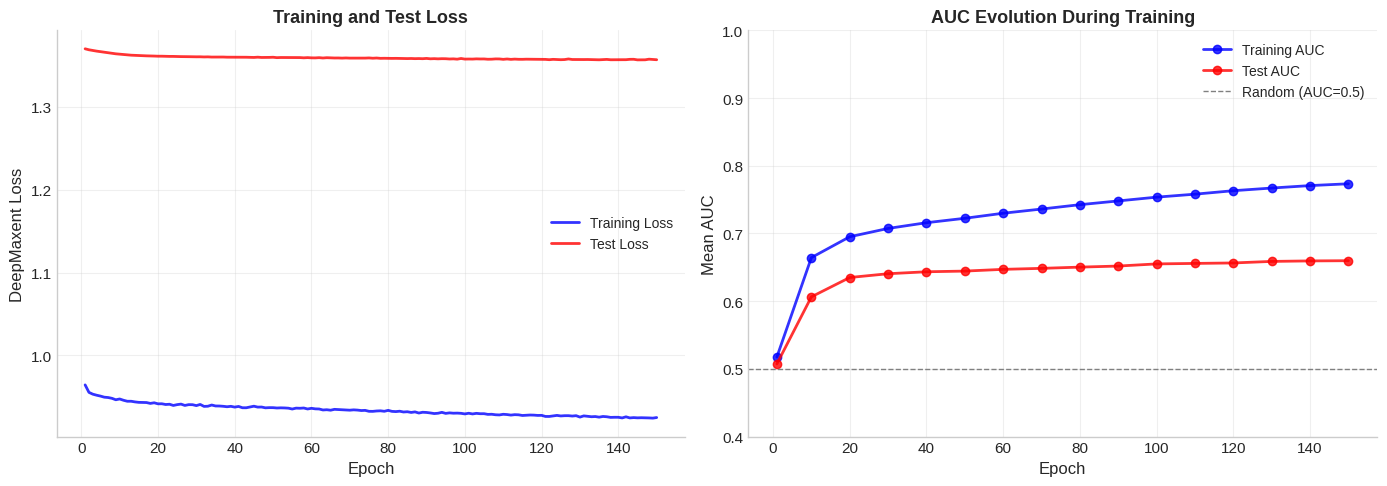


📊 FINAL METRICS
   Final Training Loss:   0.9250
   Final Test Loss: 1.3568
   Best Test Loss:  1.3566

   Final Training AUC:    0.7734
   Final Test AUC:  0.6598


In [50]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax1 = axes[0]
epochs = range(1, len(final_results['train_losses']) + 1)
ax1.plot(epochs, final_results['train_losses'], 'b-', linewidth=2, label='Training Loss', alpha=0.8)
ax1.plot(epochs, final_results['test_losses'], 'r-', linewidth=2, label='Test Loss', alpha=0.8)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('DeepMaxent Loss', fontsize=12)
ax1.set_title('Training and Test Loss', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# AUC curves
ax2 = axes[1]
train_auc_epochs = [x[0] + 1 for x in final_results['train_aucs']]
train_auc_values = [x[1] for x in final_results['train_aucs']]
test_auc_epochs = [x[0] + 1 for x in final_results['test_aucs']]
test_auc_values = [x[1] for x in final_results['test_aucs']]

ax2.plot(train_auc_epochs, train_auc_values, 'b-o', linewidth=2, markersize=6,
         label='Training AUC', alpha=0.8)
ax2.plot(test_auc_epochs, test_auc_values, 'r-o', linewidth=2, markersize=6,
         label='Test AUC', alpha=0.8)
ax2.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, label='Random (AUC=0.5)')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Mean AUC', fontsize=12)
ax2.set_title('AUC Evolution During Training', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0.4, 1.0])
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Print final metrics
print("\n📊 FINAL METRICS")
print("=" * 50)
print(f"   Final Training Loss:   {final_results['train_losses'][-1]:.4f}")
print(f"   Final Test Loss: {final_results['test_losses'][-1]:.4f}")
print(f"   Best Test Loss:  {final_results['best_test_loss']:.4f}")
print(f"\n   Final Training AUC:    {train_auc_values[-1]:.4f}")
print(f"   Final Test AUC:  {test_auc_values[-1]:.4f}")

### 7.6 Detailed AUC Analysis per Species

Let's analyze the AUC distribution across species to understand model performance:

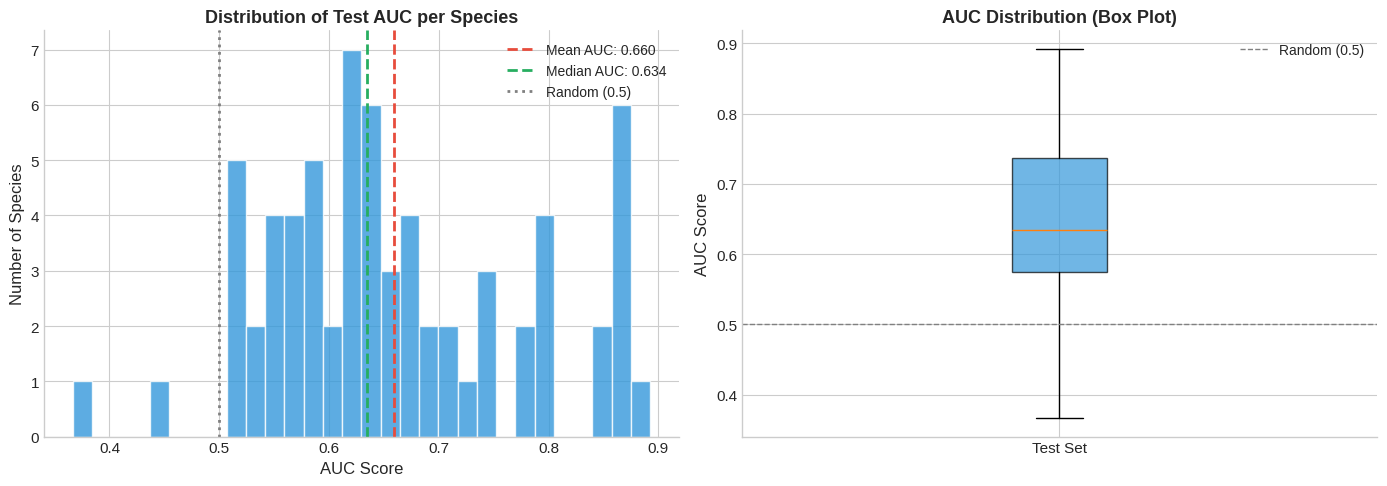


📊 TEST AUC SUMMARY
   Number of species evaluated: 67
   Mean AUC:   0.6596
   Median AUC: 0.6342
   Std AUC:    0.1171
   Min AUC:    0.3666
   Max AUC:    0.8925

   Species with AUC > 0.7: 21 (31.3%)
   Species with AUC > 0.5: 65 (97.0%)


In [52]:
# Compute detailed AUC for test set
test_mean_auc, test_species_aucs = compute_auc(final_results['model'], X_test_tensor, y_test_tensor, device)

# Distribution of AUC values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of AUC values
ax1 = axes[0]
ax1.hist(test_species_aucs, bins=30, color='#3498db', edgecolor='white', alpha=0.8)
ax1.axvline(x=np.mean(test_species_aucs), color='#e74c3c', linestyle='--', linewidth=2,
            label=f'Mean AUC: {np.mean(test_species_aucs):.3f}')
ax1.axvline(x=np.median(test_species_aucs), color='#27ae60', linestyle='--', linewidth=2,
            label=f'Median AUC: {np.median(test_species_aucs):.3f}')
ax1.axvline(x=0.5, color='gray', linestyle=':', linewidth=2, label='Random (0.5)')
ax1.set_xlabel('AUC Score', fontsize=12)
ax1.set_ylabel('Number of Species', fontsize=12)
ax1.set_title('Distribution of Test AUC per Species', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Box plot
ax2 = axes[1]
box = ax2.boxplot(test_species_aucs, vert=True, patch_artist=True)
box['boxes'][0].set_facecolor('#3498db')
box['boxes'][0].set_alpha(0.7)
ax2.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, label='Random (0.5)')
ax2.set_ylabel('AUC Score', fontsize=12)
ax2.set_title('AUC Distribution (Box Plot)', fontsize=13, fontweight='bold')
ax2.set_xticklabels(['Test Set'])
ax2.legend(fontsize=10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Summary statistics
print("\n📊 TEST AUC SUMMARY")
print("=" * 50)
print(f"   Number of species evaluated: {len(test_species_aucs)}")
print(f"   Mean AUC:   {np.mean(test_species_aucs):.4f}")
print(f"   Median AUC: {np.median(test_species_aucs):.4f}")
print(f"   Std AUC:    {np.std(test_species_aucs):.4f}")
print(f"   Min AUC:    {np.min(test_species_aucs):.4f}")
print(f"   Max AUC:    {np.max(test_species_aucs):.4f}")
print(f"\n   Species with AUC > 0.7: {sum(np.array(test_species_aucs) > 0.7)} ({100*sum(np.array(test_species_aucs) > 0.7)/len(test_species_aucs):.1f}%)")
print(f"   Species with AUC > 0.5: {sum(np.array(test_species_aucs) > 0.5)} ({100*sum(np.array(test_species_aucs) > 0.5)/len(test_species_aucs):.1f}%)")